In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load forecasting results / metrics from centralized ML-based models

In [2]:
dataset = 'dundee'  # dundee | porto | boulder | paloalto

In [3]:
# Read Baselines (ARIMA, SARIMA, SARIMAX)
baselines_pred = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__ALL_BASELINES__model.v4.pickle')[['power_next', 'ARIMA', 'SARIMA', 'SARIMAX']]
baselines_metrics = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__ALL_BASELINES__model.metrics.v4.pickle')

# Drop timezone awareness
baselines_pred.index = baselines_pred.index.set_levels(
    baselines_pred.index.levels[1].tz_localize(None),
    level=1
)

# Read XGBoost
xgb_pred = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__XGBoost_BOTH_DEMAND_PERIODS__model.v4.pickle')
xgb_metrics= pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__XGBoost_BOTH_DEMAND_PERIODS__model.metrics.v4.pickle')

# Drop timezone awareness
xgb_pred.index = xgb_pred.index.set_levels(
    xgb_pred.index.levels[1].tz_localize(None),
    level=1
)

# Read [Bi]LSTM/GRU
lstm_pred = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__LSTM__model.v4.pickle')
lstm_metrics = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__LSTM__model.metrics.v4.pickle')
gru_pred = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__GRU__model.v4.pickle')
gru_metrics = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__GRU__model.metrics.v4.pickle')
bilstm_pred = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__BiLSTM__model.v4.pickle')
bilstm_metrics = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__BiLSTM__model.metrics.v4.pickle')
bigru_pred = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__BiGRU__model.v4.pickle')
bigru_metrics = pd.read_pickle(f'../data/pkl/{dataset}_data.demand_12H.EVSE__BiGRU__model.metrics.v4.pickle')

In [4]:
centralized_ml_preds = lstm_pred.join(
    gru_pred.drop('power_next', axis=1)
).join(
    bilstm_pred.drop('power_next', axis=1)
).join(
    bigru_pred.drop('power_next', axis=1)
).join(
    xgb_pred.drop('power_next', axis=1)
).join(
    baselines_pred.drop('power_next', axis=1),
)

# Visualize results

In [5]:
if dataset == 'dundee':
    EVSE_OID = 50692.0
    min_bound, max_bound = '2018-10-20', '2018-11-20'
elif dataset == 'porto':
    EVSE_OID = 'inescevse007'
    min_bound, max_bound = '2025-05-23', '2025-06-20'
elif dataset == 'boulder':
    EVSE_OID = 'BOULDER / REC CENTER ST2'
    min_bound, max_bound = '2021-03-01', '2021-03-30'
elif dataset == 'paloalto':
    EVSE_OID = 'PALO ALTO CA / CAMBRIDGE #2'
    min_bound, max_bound = '2020-10-01', '2020-10-30'

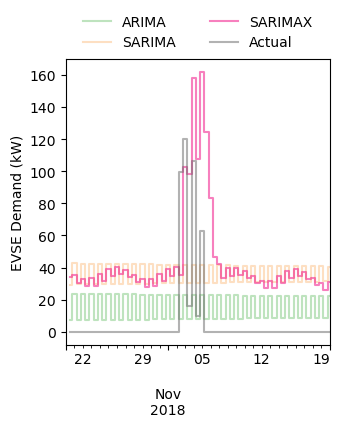

In [6]:
fig, ax = plt.subplots(1,1, figsize=(3.5, 4.5), sharex=True)

centralized_ml_preds.loc[
    pd.IndexSlice[
        EVSE_OID, 
        min_bound:max_bound
    ], 
    ['ARIMA', 'SARIMA', 'SARIMAX', 'power_next']
].reset_index(level=0, drop=True).plot(cmap='Accent', drawstyle='steps-mid', alpha=0.5, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('EVSE Demand (kW)')
ax.set_xlim(min_bound, max_bound)

plt.legend(['ARIMA', 'SARIMA', 'SARIMAX', 'Actual'], ncol=2, loc='upper center', columnspacing=2.5, bbox_to_anchor=(0.5, 1.2), frameon=False)

plt.tight_layout()
plt.savefig(f'../data/fig/{dataset}-centralized-{str(EVSE_OID).replace(" / ", "_")}-test-set.v6.pdf', dpi=300)

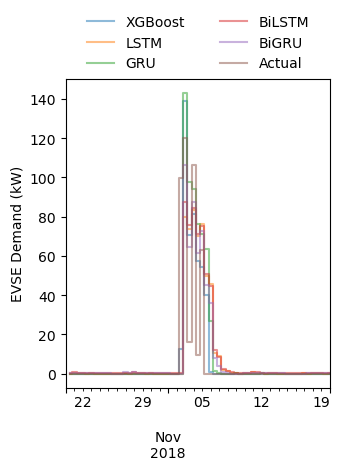

In [7]:
fig, ax = plt.subplots(1,1, figsize=(3.5, 5), sharex=True)

centralized_ml_preds.loc[
    pd.IndexSlice[
        EVSE_OID, 
        min_bound:max_bound
    ], 
    ['XGBoost', 'LSTM', 'GRU', 'BiLSTM', 'BiGRU', 'power_next']
].reset_index(level=0, drop=True).plot(drawstyle='steps-mid', alpha=0.5, ax=ax)

ax.set_xlabel(None)
ax.set_ylabel('EVSE Demand (kW)')
ax.set_xlim(min_bound, max_bound)

plt.legend(['XGBoost', 'LSTM', 'GRU', 'BiLSTM', 'BiGRU', 'Actual'], ncol=2, loc='upper center', columnspacing=2.5, bbox_to_anchor=(0.5, 1.25), frameon=False)

plt.tight_layout()
plt.savefig(f'../data/fig/{dataset}-xgb-lstm-{str(EVSE_OID).replace(" / ", "_")}-test-set.v6.pdf', dpi=300)

# Illustrate metric results

In [8]:
centralized_ml_metrics = lstm_metrics.join(
    gru_metrics
).join(
    bilstm_metrics
).join(
    bigru_metrics
).join(
    xgb_metrics
).join(
    baselines_metrics,
).groupby(level=0).describe().T

In [ ]:
centralized_ml_metrics.loc[
    pd.IndexSlice[:, ['25%', '50%', '75%']], 
    # ['0_MASE_pct', '1_SMAPE_pct', '2_MAAPE_rads', '3_WAPE_pct', '4_RMSE_kW', '5_MAE_kW', '6_R2']
    :
].round(4)

In [ ]:
# For LaTeX
print(
    centralized_ml_metrics.loc[
        pd.IndexSlice[
            ['ARIMA', 'SARIMA', 'SARIMAX', 'XGBoost', 'LSTM', 'GRU', 'BiLSTM', 'BiGRU'], 
            ['25%', '50%', '75%']
        ], 
        ['0_MASE_pct', '1_SMAPE_pct', '2_MAAPE_rads', '3_WAPE_pct', '4_RMSE_kW', '5_MAE_kW', '6_R2']
    ].round(2).groupby(level=0, sort=False).apply(
        lambda l: l.apply(
            lambda k: '; '.join(k.values.astype(str).tolist())
        )
    ).to_latex()
)